#  Análisis de la Deserción Escolar en Bolivia — Caso 1 (Google Colab)

**Proyecto:** Machine Learning aplicado a la Encuesta de Hogares 2025 (EH2025) del INE Bolivia  
**Caso de estudio:** Caso 1 — Análisis de la Deserción Escolar  


##  Instalación de dependencias

Google Colab ya incluye pandas, numpy, scikit-learn, matplotlib, seaborn y folium. Solo necesitamos instalar **pyreadstat** para leer archivos .sav de SPSS.

In [4]:
# ============================================================
# CELDA 1: Instalación de dependencias
# ============================================================
# pyreadstat: para leer archivos .sav de SPSS
!pip install pyreadstat -q

# Verificar instalación
import pyreadstat
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import folium

print("✓ Dependencias instaladas correctamente:")
print(f"  pyreadstat: {pyreadstat.__version__}")
print(f"  pandas:     {pd.__version__}")
print(f"  numpy:      {np.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  matplotlib: {matplotlib.__version__}")
print(f"  folium:     {folium.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 10.4 MB/s eta 0:00:00
✓ Dependencias instaladas correctamente:
  pyreadstat: 1.3.6
  pandas:     2.2.3
  numpy:      2.1.3
  scikit-learn: 1.6.1
  matplotlib: 3.10.0
  folium:     0.20.0


## C Carga de archivos .sav

### Subir archivos desde tu computadora (rápido)
Sube los archivos `EH2025_Persona.sav` y `EH2025_Vivienda_1.sav` (y los demás si los tienes). El total pesa aproximadamente 120 MB.



In [5]:
# ============================================================
# OPCIÓN A: Subir archivos desde tu computadora
# ============================================================
import os
from google.colab import files

# Crear carpeta de datos
os.makedirs('/content/data', exist_ok=True)
os.makedirs('/content/outputs/imagenes', exist_ok=True)

print("📁 Selecciona los archivos .sav de la EH2025 para subirlos:")
print("   (Puedes seleccionar múltiples archivos con Ctrl+Clic)")
print()
uploaded = files.upload()

# Mover archivos subidos a /content/data/
for filename, content in uploaded.items():
    filepath = f'/content/data/{filename}'
    with open(filepath, 'wb') as f:
        f.write(content)
    size_mb = len(content) / (1024*1024)
    print(f"  ✓ {filename} subido ({size_mb:.1f} MB)")

print()
print("Archivos en /content/data/:")
!ls -la /content/data/

📁 Selecciona los archivos .sav de la EH2025 para subirlos:
   (Puedes seleccionar múltiples archivos con Ctrl+Clic)



Saving EH2025_Vivienda_1.sav to EH2025_Vivienda_1.sav
Saving EH2025_Persona.sav to EH2025_Persona.sav
Saving EH2025_Equipamiento.sav to EH2025_Equipamiento.sav
Saving EH2025_Discriminacion.sav to EH2025_Discriminacion.sav
Saving EH2025_Gastos_No_Alimentarios.sav to EH2025_Gastos_No_Alimentarios.sav
Saving EH2025_Gastos_Alimentarios.sav to EH2025_Gastos_Alimentarios.sav
Saving EH2025_Seguridad_Alimentaria.sav to EH2025_Seguridad_Alimentaria.sav
  ✓ EH2025_Vivienda_1.sav subido (3.8 MB)
  ✓ EH2025_Persona.sav subido (26.1 MB)
  ✓ EH2025_Equipamiento.sav subido (15.8 MB)
  ✓ EH2025_Discriminacion.sav subido (1.9 MB)
  ✓ EH2025_Gastos_No_Alimentarios.sav subido (2.0 MB)
  ✓ EH2025_Gastos_Alimentarios.sav subido (72.5 MB)
  ✓ EH2025_Seguridad_Alimentaria.sav subido (0.9 MB)

Archivos en /content/data/:
total 125964
drwxr-xr-x 2 root root     4096 Sep 17 20:57 .
drwxr-xr-x 1 root root     4096 Sep 17 20:57 ..
-rw-r--r-- 1 root root  1998936 Sep 17 20:57 EH2025_Discriminacion.sav
-rw-r--r-- 1

##  Configuración global

Definimos rutas, paleta de colores y estilo de gráficos.

In [6]:
# ============================================================
# CELDA 3: Configuración global
# ============================================================
import os
import sys
import warnings
import json
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')

# Configuración de fuentes
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style("whitegrid", {'axes.grid': True, 'grid.alpha': 0.3})

# Rutas en Google Colab
DATA_DIR = Path('/content/data')
OUTPUTS_DIR = Path('/content/outputs')
IMAGES_DIR = OUTPUTS_DIR / 'imagenes'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

#paleta de colores
PALETTE = {
    'primary':   '#0B5394',  # azul institucional
    'secondary': '#38761D',  # verde
    'accent':    '#B45F06',  # ámbar
    'danger':    '#990000',  # rojo
    'neutral':   '#5F6368',
    'bg':        '#F8F9FA',
}

# Verificar que los archivos están presentes
print("=" * 70)
print(" PROYECTO EH2025 - CASO 1: DESERCIÓN ESCOLAR EN BOLIVIA ")
print("=" * 70)
print(f"\nPython: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print(f"Directorio de datos: {DATA_DIR}")
print(f"Directorio de outputs: {OUTPUTS_DIR}")

print("\n📂 Archivos .sav disponibles:")
sav_files = list(DATA_DIR.glob('*.sav'))
for f in sav_files:
    size_mb = f.stat().st_size / (1024*1024)
    print(f"  ✓ {f.name} ({size_mb:.1f} MB)")

if not sav_files:
    print("\n⚠️  No se encontraron archivos .sav en /content/data/")
    print("   Asegúrate de haber ejecutado la Celda 2 (carga de archivos).")

 PROYECTO EH2025 - CASO 1: DESERCIÓN ESCOLAR EN BOLIVIA 

Python: 3.13.15
Pandas: 2.2.3
Directorio de datos: /content/data
Directorio de outputs: /content/outputs

📂 Archivos .sav disponibles:
  ✓ EH2025_Gastos_No_Alimentarios.sav (2.0 MB)
  ✓ EH2025_Gastos_Alimentarios.sav (72.5 MB)
  ✓ EH2025_Discriminacion.sav (1.9 MB)
  ✓ EH2025_Vivienda_1.sav (3.8 MB)
  ✓ EH2025_Persona.sav (26.1 MB)
  ✓ EH2025_Equipamiento.sav (15.8 MB)
  ✓ EH2025_Seguridad_Alimentaria.sav (0.9 MB)


---

# Parte 1: Obtención y Preprocesamiento de Datos

## 1.1 Carga de archivos .sav

Cargamos los archivos .sav usando `pyreadstat`. Esta librería preserva los metadatos (etiquetas de variables y valores) que serán útiles para la interpretación.

In [7]:
# --- 1.1 Carga de archivos .sav ---
print("Cargando archivos .sav...")
persona_df, persona_meta = pyreadstat.read_sav(DATA_DIR / "EH2025_Persona.sav", apply_value_formats=False)
vivienda_df, vivienda_meta = pyreadstat.read_sav(DATA_DIR / "EH2025_Vivienda_1.sav", apply_value_formats=False)

print(f"  - Persona:  {persona_df.shape[0]:,} filas x {persona_df.shape[1]} columnas")
print(f"  - Vivienda: {vivienda_df.shape[0]:,} filas x {vivienda_df.shape[1]} columnas")

# Cargar los demás si existen (opcionales para el Caso 1)
try:
    equipamiento_df, _ = pyreadstat.read_sav(DATA_DIR / "EH2025_Equipamiento.sav", apply_value_formats=False)
    print(f"  - Equipamiento: {equipamiento_df.shape[0]:,} filas x {equipamiento_df.shape[1]} columnas")
except:
    print("  (Equipamiento no disponible - opcional para Caso 1)")

try:
    discrim_df, _ = pyreadstat.read_sav(DATA_DIR / "EH2025_Discriminacion.sav", apply_value_formats=False)
    print(f"  - Discriminación: {discrim_df.shape[0]:,} filas x {discrim_df.shape[1]} columnas")
except:
    print("  (Discriminación no disponible - opcional para Caso 1)")

Cargando archivos .sav...
  - Persona:  39,485 filas x 276 columnas
  - Vivienda: 12,726 filas x 64 columnas
  - Equipamiento: 229,068 filas x 11 columnas
  - Discriminación: 12,358 filas x 44 columnas


## 1.2 Análisis exploratorio básico

Inspeccionamos tipos de datos, valores faltantes y etiquetas de variables.

In [8]:
# --- 1.2 Análisis exploratorio básico ---
print("Tipos de datos en Persona:")
print(persona_df.dtypes.value_counts())

print("\nValores faltantes (top 10) en Persona:")
print(persona_df.isnull().sum().sort_values(ascending=False).head(10))

# Diccionario de etiquetas de variables
var_labels = {**persona_meta.column_names_to_labels, **vivienda_meta.column_names_to_labels}
print(f"\nTotal de etiquetas de variables: {len(var_labels)}")

# Mostrar algunas etiquetas relevantes
print("\nEjemplos de etiquetas:")
for k in ['s01a_02', 's01a_03', 's03a_04', 's03b_10', 's06a_06']:
    print(f"  {k}: {var_labels.get(k, 'N/A')}")

Tipos de datos en Persona:
float64    252
object      24
Name: count, dtype: int64

Valores faltantes (top 10) en Persona:
s04f_32c1    39477
s04f_32a1    39470
s04c_21e1    39466
s04c_21e2    39466
s04f_32b1    39449
s03b_12      39427
s02a_01b     39416
s05b_06bb    39388
s04c_20a2    39359
s05b_06ab    39300
dtype: int64

Total de etiquetas de variables: 334

Ejemplos de etiquetas:
  s01a_02: ¿Es hombre o mujer?
  s01a_03: ¿Cuántos años cumplidos tiene?
  s03a_04: Durante este año, ¿se inscribió o matriculó en algún curso o grado de educación escolar, alternativa, superior o postgrado?
  s03b_10: Actualmente, ¿(…) pasa clases en el nivel y curso al que se matriculó esta gestión 2025?
  s06a_06: ¿Cuál es el material más utilizado en los pisos de esta vivienda?


## 1.3 Selección de variables clave

Seleccionamos las variables relevantes para el análisis de deserción escolar.

In [9]:
# --- 1.3 Selección de variables clave ---
# Variables de Persona (a nivel individuo)
persona_cols = [
    'folio', 'nro', 'depto', 'area', 'factor', 'upm', 'estrato',
    's01a_02',   # Sexo
    's01a_03',   # Edad
    's01a_05',   # Parentesco con jefe/a de hogar
    's01a_08',   # Primer idioma (lengua materna)
    's01a_09',   # Autoidentificación indígena
    's03a_01',   # Sabe leer y escribir
    's03a_02a',  # Nivel educativo más alto aprobado
    's03a_04',   # Se inscribió/matriculó este año (clave)
    's03a_06a',  # Nivel en que se matriculó
    's03b_10',   # Actualmente pasa clases (clave)
    's03b_12',   # Vacaciones / receso
    'aestudio',  # Años de estudio
    's04a_01',   # Trabajó la semana pasada
    's04b_12',   # Categoría ocupacional
    's04d_22a',  # Ingreso total ocupación principal
    's04c_17a',  # Salario líquido
]
persona_sel = persona_df[persona_cols].copy()
print(f"Persona seleccionada: {persona_sel.shape}")

# Variables de Vivienda (a nivel hogar)
vivienda_cols = [
    'folio', 'depto', 'area', 'totper',
    's06a_03',   # Material paredes
    's06a_05',   # Material techos
    's06a_06',   # Material pisos
    's06a_07',   # Procedencia agua
    's06a_09',   # Tipo baño
    's06a_10',   # Desagüe baño
    's06a_12',   # Energía eléctrica
    's06a_15',   # Combustible cocina
    's06a_16',   # Número de cuartos
    's06a_17',   # Cuartos para dormir
    's06a_19',   # Internet
    's06a_02a',  # Alquiler estimado (proxy riqueza)
]
vivienda_sel = vivienda_df[vivienda_cols].copy()
print(f"Vivienda seleccionada: {vivienda_sel.shape}")

Persona seleccionada: (39485, 23)
Vivienda seleccionada: (12726, 16)


## 1.4 Renombrado y construcción de variable objetivo

Renombramos variables con códigos opacos a nombres interpretables y construimos `asistencia_escolar`.

**Definición operativa:**
- `asistencia_escolar = 1` (asiste): si se matriculó este año Y (cursa actualmente O está en vacaciones)
- `asistencia_escolar = 0` (no asiste): si no se matriculó O si se matriculó pero abandonó

In [10]:
# --- 1.4 Renombrado de variables ---
rename_persona = {
    's01a_02': 'sexo',           # 1=Hombre, 2=Mujer
    's01a_03': 'edad',
    's01a_05': 'parentesco',
    's01a_08': 'idioma_materno',
    's01a_09': 'indigena',
    's03a_01': 'lee_escribe',
    's03a_02a': 'nivel_educ',
    's03a_04': 'se_matriculo',
    's03a_06a': 'nivel_matricula',
    's03b_10': 'asiste_clases',
    's03b_12': 'en_vacaciones',
    'aestudio': 'anios_estudio',
    's04a_01': 'trabajo',
    's04b_12': 'categoria_ocup',
    's04d_22a': 'ingreso_lab',
    's04c_17a': 'salario_liq',
}
persona_sel = persona_sel.rename(columns=rename_persona)

rename_vivienda = {
    's06a_03': 'mat_pared',
    's06a_05': 'mat_techo',
    's06a_06': 'mat_piso',
    's06a_07': 'procedencia_agua',
    's06a_09': 'tipo_banio',
    's06a_10': 'desague_banio',
    's06a_12': 'electricidad',
    's06a_15': 'combustible_cocina',
    's06a_16': 'n_cuartos',
    's06a_17': 'n_cuartos_dormir',
    's06a_19': 'internet',
    's06a_02a': 'alquiler_estimado',
}
vivienda_sel = vivienda_sel.rename(columns=rename_vivienda)
print("✓ Variables renombradas")

✓ Variables renombradas


In [11]:
# --- 1.5 Construcción de variable objetivo ---
# Filtrar población en edad escolar (5-19 años)
edad_min, edad_max = 5, 19
persona_sel['edad'] = pd.to_numeric(persona_sel['edad'], errors='coerce')
mask_edad = persona_sel['edad'].between(edad_min, edad_max)
print(f"Población en edad escolar ({edad_min}-{edad_max} años): {mask_edad.sum():,} personas")

pob_escolar = persona_sel[mask_edad].copy()

def compute_asistencia(row):
    sm = row['se_matriculo']
    ac = row['asiste_clases']
    ev = row['en_vacaciones']
    if sm == 1:
        if ac == 1 or ev == 1:
            return 1
        else:
            return 0  # Se matriculó pero ya no asiste → desertor
    else:
        return 0

pob_escolar['asistencia_escolar'] = pob_escolar.apply(compute_asistencia, axis=1)

n_asiste = (pob_escolar['asistencia_escolar'] == 1).sum()
n_no_asiste = (pob_escolar['asistencia_escolar'] == 0).sum()
print(f"\nDistribución de la variable objetivo:")
print(f"  - Asiste (1):     {n_asiste:,} ({n_asiste/len(pob_escolar)*100:.1f}%)")
print(f"  - No asiste (0):  {n_no_asiste:,} ({n_no_asiste/len(pob_escolar)*100:.1f}%)")

Población en edad escolar (5-19 años): 11,117 personas

Distribución de la variable objetivo:
  - Asiste (1):     5,170 (46.5%)
  - No asiste (0):  5,947 (53.5%)


## 1.5 Ingeniería de características

Convertimos variables categóricas a binarias y construimos variables derivadas a nivel hogar.

In [12]:
# --- 1.6 Variables binarias ---
pob_escolar['sexo_bin'] = (pob_escolar['sexo'] == 1).astype(int)
pob_escolar['indigena_bin'] = (pob_escolar['indigena'] == 1).astype(int)
pob_escolar['idioma_originario'] = (
    (pob_escolar['idioma_materno'] != 1) & pob_escolar['idioma_materno'].notna()
).astype(int)
pob_escolar['lee_escribe_bin'] = (pob_escolar['lee_escribe'] == 1).astype(int)
pob_escolar['trabajo_bin'] = (pob_escolar['trabajo'] == 1).astype(int)
print("✓ Variables binarias creadas")

✓ Variables binarias creadas


In [13]:
# --- 1.7 Fusión con Vivienda ---
dataset = pob_escolar.merge(vivienda_sel, on='folio', how='left', suffixes=('', '_viv'))
print(f"Dataset fusionado: {dataset.shape}")

# --- 1.8 Variables a nivel hogar ---
# Hacinamiento
dataset['n_cuartos'] = pd.to_numeric(dataset['n_cuartos'], errors='coerce')
dataset['totper'] = pd.to_numeric(dataset['totper'], errors='coerce')
dataset['hacinamiento'] = dataset['totper'] / dataset['n_cuartos'].replace(0, np.nan)
dataset['hacinamiento'] = dataset['hacinamiento'].fillna(dataset['hacinamiento'].median())

# Índice de servicios básicos (0-3)
dataset['acceso_agua'] = dataset['procedencia_agua'].isin([1, 2, 3]).astype(int)
dataset['acceso_electricidad'] = (dataset['electricidad'] == 1).astype(int)
dataset['acceso_banio'] = (dataset['tipo_banio'].notna() & (dataset['tipo_banio'] != 6)).astype(int)
dataset['indice_servicios'] = dataset['acceso_agua'] + dataset['acceso_electricidad'] + dataset['acceso_banio']

# Material de vivienda
dataset['piso_adecuado'] = (~dataset['mat_piso'].isin([1])).astype(int)
dataset['pared_adecuada'] = dataset['mat_pared'].isin([1, 2, 4]).astype(int)
dataset['internet_bin'] = (dataset['internet'] == 1).astype(int)

# --- 1.9 Variables del jefe/a de hogar ---
jefe_cols = ['folio', 'sexo', 'edad', 'nivel_educ', 'anios_estudio', 'categoria_ocup', 'ingreso_lab']
persona_jefe = persona_sel[persona_sel['parentesco'] == 1][jefe_cols].rename(
    columns={c: f'jefe_{c}' for c in jefe_cols if c != 'folio'}
).drop_duplicates(subset='folio')
dataset = dataset.merge(persona_jefe, on='folio', how='left')

# Ingreso per cápita del hogar
ingreso_hogar = persona_sel.groupby('folio')['ingreso_lab'].sum().reset_index()
ingreso_hogar.columns = ['folio', 'ingreso_total_hogar']
dataset = dataset.merge(ingreso_hogar, on='folio', how='left')
dataset['ingreso_percapita'] = dataset['ingreso_total_hogar'] / dataset['totper']
dataset['ingreso_percapita'] = dataset['ingreso_percapita'].fillna(0)
dataset['log_ingreso_pc'] = np.log1p(dataset['ingreso_percapita'].clip(lower=0))
dataset['jefe_anios_estudio'] = pd.to_numeric(dataset['jefe_anios_estudio'], errors='coerce').fillna(0)

# --- 1.10 Mapeo final ---
depto_map = {1: 'Chuquisaca', 2: 'La Paz', 3: 'Cochabamba', 4: 'Oruro',
             5: 'Potosí', 6: 'Tarija', 7: 'Santa Cruz', 8: 'Beni', 9: 'Pando'}
dataset['depto_nombre'] = dataset['depto'].map(depto_map)
dataset['area_nombre'] = dataset['area'].map({1: 'Urbana', 2: 'Rural', 3: 'Urbana'})

print(f"\n✓ Dataset final: {dataset.shape}")

Dataset fusionado: (11117, 44)

✓ Dataset final: (11117, 63)


In [14]:
# --- 1.11 Guardar dataset_procesado.csv ---
dataset.to_csv(OUTPUTS_DIR / "dataset_procesado.csv", index=False, encoding='utf-8')
print(f"✓ Dataset guardado: {OUTPUTS_DIR / 'dataset_procesado.csv'}")
print(f"  Tamaño: {(OUTPUTS_DIR / 'dataset_procesado.csv').stat().st_size / 1024:.1f} KB")

# Estadísticas descriptivas
print("\nResumen estadístico de variables clave:")
print(dataset[['edad', 'sexo_bin', 'indigena_bin', 'asistencia_escolar',
               'hacinamiento', 'indice_servicios', 'ingreso_percapita',
               'jefe_anios_estudio']].describe().T)

✓ Dataset guardado: /content/outputs/dataset_procesado.csv
  Tamaño: 3066.5 KB

Resumen estadístico de variables clave:
                      count         mean          std  min  25%         50%  \
edad                11117.0    11.999550     4.127151  5.0  9.0   12.000000   
sexo_bin            11117.0     0.510569     0.499911  0.0  0.0    1.000000   
indigena_bin        11117.0     0.110911     0.314036  0.0  0.0    0.000000   
asistencia_escolar  11117.0     0.465054     0.498800  0.0  0.0    0.000000   
hacinamiento        11117.0     1.970071     1.194709  0.2  1.2    1.666667   
indice_servicios    11117.0     2.691553     0.508946  1.0  2.0    3.000000   
ingreso_percapita   11117.0  1156.056983  3938.044360  0.0  0.0  140.000000   
jefe_anios_estudio  11117.0    10.468562     4.779449  0.0  6.0   12.000000   

                       75%            max  
edad                  15.0      19.000000  
sexo_bin               1.0       1.000000  
indigena_bin           0.0       1.0

---

#  Parte 2: Análisis Exploratorio y Visualización

Generamos al menos 4 visualizaciones distintas según la rúbrica.

In [15]:
import folium
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 2.1 Tasas por departamento ---
tasas_depto = dataset.groupby('depto_nombre').agg(
    tasa_asistencia=('asistencia_escolar', 'mean'),
    n_estudiantes=('asistencia_escolar', 'count'),
    ingreso_pc_prom=('ingreso_percapita', 'mean'),
).reset_index()
tasas_depto['tasa_no_asistencia'] = 1 - tasas_depto['tasa_asistencia']
tasas_depto = tasas_depto.sort_values('tasa_no_asistencia', ascending=False)
print("Tasas por departamento:")
print(tasas_depto.to_string(index=False))

# --- 2.2 Tasa por área ---
tasas_area = dataset.groupby('area_nombre').agg(
    tasa_asistencia=('asistencia_escolar', 'mean'),
    n=('asistencia_escolar', 'count'),
).reset_index()
print("\nTasas por área:")
print(tasas_area.to_string(index=False))

Tasas por departamento:
depto_nombre  tasa_asistencia  n_estudiantes  ingreso_pc_prom  tasa_no_asistencia
  Chuquisaca         0.242424            792      1726.520072            0.757576
       Oruro         0.314650            785      1270.237069            0.685350
      Tarija         0.335501            769      1932.726690            0.664499
  Cochabamba         0.361999           1721      1288.474371            0.638001
        Beni         0.384139            807       866.617794            0.615861
      Potosí         0.422195            829       987.862222            0.577805
  Santa Cruz         0.445116           2150      1006.670889            0.554884
       Pando         0.529015            741      1293.428171            0.470985
      La Paz         0.729687           2523       849.204614            0.270313

Tasas por área:
area_nombre  tasa_asistencia    n
      Rural         0.393038 2758
     Urbana         0.488814 8359


## 2.1 VISUALIZACIÓN 1: Gráfico de barras comparativo

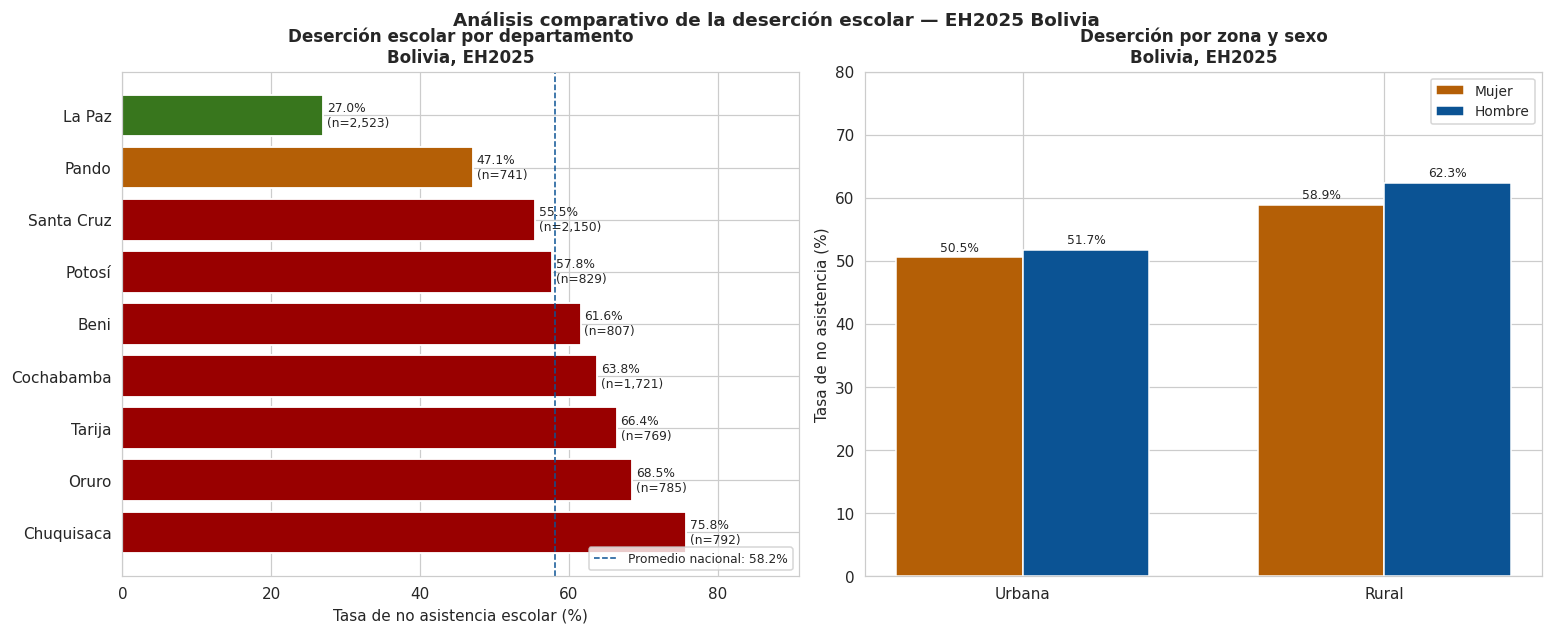

✓ Guardado: 01_barras_comparativas.png


In [16]:
# --- VISUALIZACIÓN 1: Gráfico de barras comparativo ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# Subplot 1: por departamento
colors_depto = [PALETTE['danger'] if t > 0.55 else
                PALETTE['accent'] if t > 0.45 else
                PALETTE['secondary']
                for t in tasas_depto['tasa_no_asistencia']]
axes[0].barh(tasas_depto['depto_nombre'],
             tasas_depto['tasa_no_asistencia']*100,
             color=colors_depto, edgecolor='white', linewidth=1.2)
axes[0].set_xlabel('Tasa de no asistencia escolar (%)', fontsize=10)
axes[0].set_title('Deserción escolar por departamento\nBolivia, EH2025',
                  fontsize=11, fontweight='bold')
axes[0].axvline(tasas_depto['tasa_no_asistencia'].mean()*100,
                color=PALETTE['primary'], linestyle='--', linewidth=1,
                label=f'Promedio nacional: {tasas_depto["tasa_no_asistencia"].mean()*100:.1f}%')
axes[0].legend(fontsize=8, loc='lower right')
for i, (v, n) in enumerate(zip(tasas_depto['tasa_no_asistencia']*100,
                                tasas_depto['n_estudiantes'])):
    axes[0].text(v + 0.5, i, f'{v:.1f}%\n(n={n:,})', va='center', fontsize=8)
axes[0].set_xlim(0, max(tasas_depto['tasa_no_asistencia']*100) * 1.2)

# Subplot 2: por área y sexo
grp_sex_area = dataset.groupby(['area_nombre', 'sexo_bin'])['asistencia_escolar'].mean().unstack()
grp_sex_area.columns = ['Mujer', 'Hombre']
grp_sex_area = grp_sex_area.reindex(['Urbana', 'Rural'])
x_pos = np.arange(len(grp_sex_area))
w = 0.35
axes[1].bar(x_pos - w/2, (1 - grp_sex_area['Mujer'])*100, w, label='Mujer',
            color=PALETTE['accent'], edgecolor='white')
axes[1].bar(x_pos + w/2, (1 - grp_sex_area['Hombre'])*100, w, label='Hombre',
            color=PALETTE['primary'], edgecolor='white')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(grp_sex_area.index)
axes[1].set_ylabel('Tasa de no asistencia (%)', fontsize=10)
axes[1].set_title('Deserción por zona y sexo\nBolivia, EH2025', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
for i, (col_name, col) in enumerate([('Mujer', -w/2), ('Hombre', w/2)]):
    for j, idx in enumerate(grp_sex_area.index):
        v = (1 - grp_sex_area.loc[idx, col_name]) * 100
        axes[1].text(j + col, v + 1, f'{v:.1f}%', ha='center', fontsize=8)
axes[1].set_ylim(0, 80)

fig.suptitle('Análisis comparativo de la deserción escolar — EH2025 Bolivia',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig(IMAGES_DIR / "01_barras_comparativas.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Guardado: 01_barras_comparativas.png")

## 2.2 VISUALIZACIÓN 2: Relación edad-asistencia e ingreso

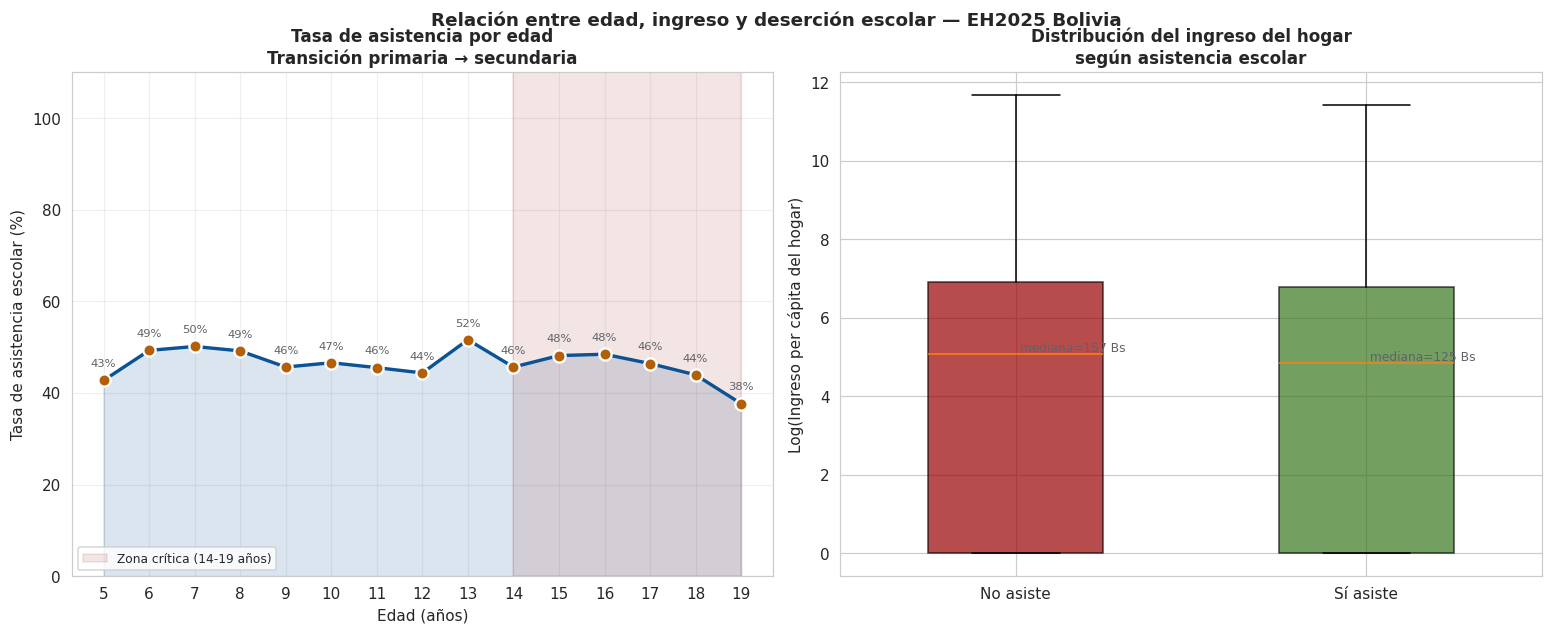

✓ Guardado: 02_relacion_edad_ingreso.png


In [17]:
# --- VISUALIZACIÓN 2: Relación edad-asistencia e ingreso ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# Subplot 1: tasa de asistencia por edad
edad_asist = dataset.groupby('edad')['asistencia_escolar'].agg(['mean', 'count']).reset_index()
axes[0].plot(edad_asist['edad'], edad_asist['mean']*100, marker='o',
             linewidth=2.2, markersize=8, color=PALETTE['primary'],
             markerfacecolor=PALETTE['accent'],
             markeredgecolor='white', markeredgewidth=1.5)
axes[0].fill_between(edad_asist['edad'], 0, edad_asist['mean']*100,
                     alpha=0.15, color=PALETTE['primary'])
axes[0].set_xlabel('Edad (años)', fontsize=10)
axes[0].set_ylabel('Tasa de asistencia escolar (%)', fontsize=10)
axes[0].set_title('Tasa de asistencia por edad\nTransición primaria → secundaria',
                  fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(5, 20))
axes[0].axvspan(14, 19, alpha=0.1, color=PALETTE['danger'],
                label='Zona crítica (14-19 años)')
axes[0].legend(fontsize=8, loc='lower left')
for x, y, n in zip(edad_asist['edad'], edad_asist['mean']*100, edad_asist['count']):
    axes[0].text(x, y + 3, f'{y:.0f}%', ha='center', fontsize=7.5, color=PALETTE['neutral'])
axes[0].set_ylim(0, 110)

# Subplot 2: boxplot ingreso per cápita por asistencia
data_box = [dataset.loc[dataset['asistencia_escolar']==0, 'log_ingreso_pc'].values,
            dataset.loc[dataset['asistencia_escolar']==1, 'log_ingreso_pc'].values]
bp = axes[1].boxplot(data_box, labels=['No asiste', 'Sí asiste'],
                      patch_artist=True, widths=0.5, showfliers=False)
for patch, color in zip(bp['boxes'], [PALETTE['danger'], PALETTE['secondary']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Log(Ingreso per cápita del hogar)', fontsize=10)
axes[1].set_title('Distribución del ingreso del hogar\nsegún asistencia escolar',
                  fontsize=11, fontweight='bold')
for i, d in enumerate(data_box, 1):
    med = np.median(d)
    axes[1].text(i, med, f' mediana={np.expm1(med):.0f} Bs', va='bottom',
                 fontsize=8, color=PALETTE['neutral'])

fig.suptitle('Relación entre edad, ingreso y deserción escolar — EH2025 Bolivia',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig(IMAGES_DIR / "02_relacion_edad_ingreso.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Guardado: 02_relacion_edad_ingreso.png")

## 2.3 VISUALIZACIÓN 3: Mapa interactivo Folium

El mapa se muestra directamente en Colab y también se guarda como HTML.

In [18]:
# --- VISUALIZACIÓN 3: Mapa interactivo Folium ---
depto_coords = {
    'La Paz':     (-16.5000, -68.1500),
    'Santa Cruz': (-17.7833, -63.1821),
    'Cochabamba':  (-17.3895, -66.1568),
    'Potosí':     (-19.5836, -65.7531),
    'Oruro':      (-17.9833, -67.1500),
    'Chuquisaca': (-19.0471, -65.2596),
    'Tarija':     (-21.5333, -64.7333),
    'Beni':       (-14.8333, -64.9000),
    'Pando':      (-11.0333, -68.7667),
}

m = folium.Map(location=[-16.5, -64.5], zoom_start=5, tiles='CartoDB positron')

for _, row in tasas_depto.iterrows():
    nombre = row['depto_nombre']
    if nombre in depto_coords:
        lat, lon = depto_coords[nombre]
        tasa_no = row['tasa_no_asistencia'] * 100
        radius = np.sqrt(row['n_estudiantes']) * 0.8
        if tasa_no > 60:
            color = PALETTE['danger']
        elif tasa_no > 50:
            color = PALETTE['accent']
        else:
            color = PALETTE['secondary']
        popup_text = f"""<b>{nombre}</b><br>
        Tasa de no asistencia: <b>{tasa_no:.1f}%</b><br>
        Estudiantes (5-19 años): {row['n_estudiantes']:,}<br>
        Ingreso per cápita promedio: {row['ingreso_pc_prom']:.0f} Bs<br>
        Tasa de asistencia: {row['tasa_asistencia']*100:.1f}%"""
        folium.CircleMarker(
            location=[lat, lon], radius=radius,
            popup=folium.Popup(popup_text, max_width=300),
            color=color, fill=True, fill_color=color,
            fill_opacity=0.6, weight=2,
        ).add_to(m)
        folium.Marker(
            location=[lat, lon - 0.3],
            icon=folium.DivIcon(html=f"""<div style='font-size:9pt;font-weight:bold;
                color:#333;background:white;padding:2px 5px;border-radius:3px;
                border:1px solid #ccc;white-space:nowrap;'>{nombre}: {tasa_no:.0f}%</div>"""),
        ).add_to(m)

# Leyenda
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 10px 14px; border-radius: 5px;
            border: 2px solid #ccc; font-size: 11px;">
  <p style="margin:0 0 6px 0; font-weight:bold; color:#333;">Tasa de no asistencia escolar</p>
  <p style="margin:2px 0;"><span style="color:#990000;">●</span> Alta (>60%)</p>
  <p style="margin:2px 0;"><span style="color:#B45F06;">●</span> Media (50-60%)</p>
  <p style="margin:2px 0;"><span style="color:#38761D;">●</span> Baja (<50%)</p>
  <hr style="margin:6px 0;">
  <p style="margin:0; font-size:9px; color:#666;">Radio ∝ n estudiantes</p>
  <p style="margin:2px 0;font-size:9px;color:#666;">Fuente: EH2025 - INE Bolivia</p>
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

# Guardar
m.save(str(OUTPUTS_DIR / "mapa_desercion_departamental.html"))
print(f"✓ Mapa guardado: {OUTPUTS_DIR / 'mapa_desercion_departamental.html'}")

# Mostrar en Colab
m

✓ Mapa guardado: /content/outputs/mapa_desercion_departamental.html


## 2.4 VISUALIZACIÓN 4: Clustering K-means

Aplicamos K-means (k=3) sobre los departamentos y visualizamos con PCA 2D.

In [21]:
# --- VISUALIZACIÓN 4: Clustering K-means ---
features_cluster = ['tasa_no_asistencia', 'ingreso_pc_prom', 'n_estudiantes']
X_cluster = tasas_depto[features_cluster].copy()
X_cluster['n_estudiantes'] = np.log1p(X_cluster['n_estudiantes'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-means con k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
tasas_depto['cluster'] = kmeans.fit_predict(X_scaled)

# Perfiles de clusters
cluster_profiles = tasas_depto.groupby('cluster').agg({
    'tasa_no_asistencia': 'mean',
    'ingreso_pc_prom': 'mean',
    'n_estudiantes': 'mean'
}).reset_index().sort_values('tasa_no_asistencia', ascending=False)

cluster_labels = {
    cluster_profiles.iloc[0]['cluster']: 'Riesgo alto',
    cluster_profiles.iloc[1]['cluster']: 'Riesgo medio',
    cluster_profiles.iloc[2]['cluster']: 'Riesgo bajo',
}
tasas_depto['cluster_label'] = tasas_depto['cluster'].map(cluster_labels)

print("Perfiles de clusters:")
print(cluster_profiles.to_string(index=False))
print("\nResumen clusters:")
for label in ['Riesgo alto', 'Riesgo medio', 'Riesgo bajo']:
    deptos = tasas_depto.loc[tasas_depto['cluster_label']==label, 'depto_nombre'].tolist()
    print(f"  - {label}: {', '.join(deptos)}")

Perfiles de clusters:
 cluster  tasa_no_asistencia  ingreso_pc_prom  n_estudiantes
       2            0.711038      1829.623381     780.500000
       0            0.587500      1104.536314     790.500000
       1            0.487733      1048.116625    2131.333333

Resumen clusters:
  - Riesgo alto: Chuquisaca, Tarija
  - Riesgo medio: Oruro, Beni, Potosí, Pando
  - Riesgo bajo: Cochabamba, Santa Cruz, La Paz


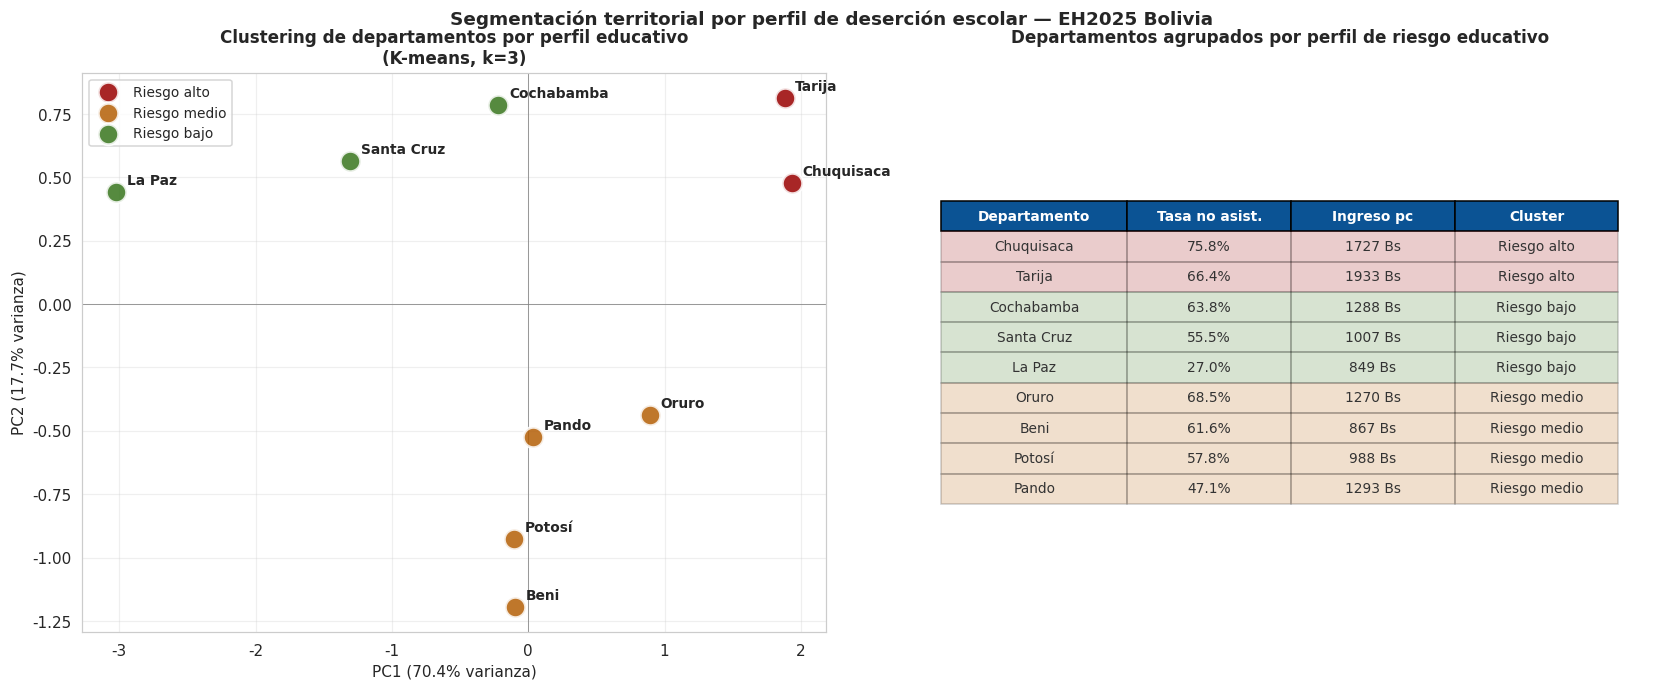

✓ Guardado: 04_clustering_kmeans.png


In [22]:
# Visualización 2D con PCA
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
cluster_colors = {'Riesgo alto': PALETTE['danger'],
                  'Riesgo medio': PALETTE['accent'],
                  'Riesgo bajo': PALETTE['secondary']}
for label in ['Riesgo alto', 'Riesgo medio', 'Riesgo bajo']:
    mask = tasas_depto['cluster_label'] == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=180,
                    c=cluster_colors[label], edgecolors='white',
                    linewidth=2, label=label, alpha=0.85, zorder=3)
for i, depto in enumerate(tasas_depto['depto_nombre']):
    axes[0].annotate(depto, (X_pca[i, 0], X_pca[i, 1]),
                     xytext=(7, 5), textcoords='offset points',
                     fontsize=9, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=10)
axes[0].set_title('Clustering de departamentos por perfil educativo\n(K-means, k=3)',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9, loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)

# Tabla de clusters
axes[1].axis('off')
table_data = tasas_depto[['depto_nombre', 'tasa_no_asistencia', 'ingreso_pc_prom', 'cluster_label']].copy()
table_data['tasa_no_asistencia'] = (table_data['tasa_no_asistencia'] * 100).round(1).astype(str) + '%'
table_data['ingreso_pc_prom'] = table_data['ingreso_pc_prom'].round(0).astype(int).astype(str) + ' Bs'
table_data.columns = ['Departamento', 'Tasa no asist.', 'Ingreso pc', 'Cluster']
table_data = table_data.sort_values('Cluster')
col_colors = [cluster_colors[c] for c in table_data['Cluster']]
table = axes[1].table(cellText=table_data.values, colLabels=table_data.columns,
                      cellLoc='center', loc='center', colWidths=[0.25, 0.22, 0.22, 0.22])
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 1.5)
for i, c in enumerate(col_colors):
    for j in range(4):
        table[(i+1, j)].set_facecolor(c); table[(i+1, j)].set_alpha(0.2)
        table[(i+1, j)].set_text_props(color='#333')
for j in range(4):
    table[(0, j)].set_facecolor('#0B5394')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
axes[1].set_title('Departamentos agrupados por perfil de riesgo educativo',
                  fontsize=11, fontweight='bold', pad=20)

fig.suptitle('Segmentación territorial por perfil de deserción escolar — EH2025 Bolivia',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig(IMAGES_DIR / "04_clustering_kmeans.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Guardado: 04_clustering_kmeans.png")

---

# Parte 3: Modelo de Machine Learning

## 3.1 Definición del problema y preparación de features

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay)

# Features finales
feature_cols = [
    'edad', 'sexo_bin', 'indigena_bin', 'idioma_originario', 'lee_escribe_bin',
    'area_nombre', 'depto_nombre',
    'hacinamiento', 'indice_servicios', 'piso_adecuado', 'pared_adecuada',
    'internet_bin', 'log_alquiler',
    'log_ingreso_pc',
    'jefe_anios_estudio', 'jefe_edad', 'jefe_sexo',
    'trabajo_bin',
]

# Asegurar que jefe_edad y jefe_sexo existan
if 'jefe_edad' not in dataset.columns:
    dataset['jefe_edad'] = 0
if 'jefe_sexo' not in dataset.columns:
    dataset['jefe_sexo'] = 1

# Crear log_alquiler
dataset['alquiler_estimado'] = pd.to_numeric(dataset['alquiler_estimado'], errors='coerce').fillna(0)
dataset['log_alquiler'] = np.log1p(dataset['alquiler_estimado'].clip(lower=0))

model_df = dataset[['asistencia_escolar'] + feature_cols].copy()
model_df['jefe_edad'] = pd.to_numeric(model_df['jefe_edad'], errors='coerce').fillna(model_df['jefe_edad'].median())
model_df['jefe_sexo'] = pd.to_numeric(model_df['jefe_sexo'], errors='coerce').fillna(1)

# One-hot encoding
categorical_cols = ['area_nombre', 'depto_nombre']
model_df_encoded = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)
print(f"Dataset para modelado: {model_df_encoded.shape}")
print(f"Variables predictoras: {model_df_encoded.shape[1] - 1}")

Dataset para modelado: (11117, 26)
Variables predictoras: 25


In [24]:
# --- 3.2 División estratificada 80/20 ---
X = model_df_encoded.drop('asistencia_escolar', axis=1)
y = model_df_encoded['asistencia_escolar']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} muestras (asiste={y_train.mean()*100:.1f}%)")
print(f"Test:  {X_test.shape[0]:,} muestras (asiste={y_test.mean()*100:.1f}%)")

# Escalar para regresión logística
scaler_ml = StandardScaler()
X_train_scaled = scaler_ml.fit_transform(X_train)
X_test_scaled = scaler_ml.transform(X_test)

Train: 8,893 muestras (asiste=46.5%)
Test:  2,224 muestras (asiste=46.5%)


## 3.2 Modelo 1: Regresión Logística

In [25]:
# --- 3.3 Modelo 1: Regresión Logística ---
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print("Regresión Logística:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"  F1-score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_lr):.4f}")

Regresión Logística:
  Accuracy:  0.6277
  Precision: 0.6170
  Recall:    0.5251
  F1-score:  0.5674
  AUC-ROC:   0.6737


## 3.3 Modelo 2: Random Forest

In [26]:
# --- 3.4 Modelo 2: Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=20,
    random_state=42, class_weight='balanced', n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1-score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest:
  Accuracy:  0.6754
  Precision: 0.6801
  Recall:    0.5696
  F1-score:  0.6200
  AUC-ROC:   0.7377


## 3.4 Comparación de modelos

In [27]:
# --- 3.5 Comparación de modelos ---
comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC'],
    'Regresión Logística': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_proba_lr),
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_proba_rf),
    ],
})
print("Comparación de modelos:")
print(comparison.to_string(index=False))

Comparación de modelos:
  Métrica  Regresión Logística  Random Forest
 Accuracy             0.627698       0.675360
Precision             0.617045       0.680139
   Recall             0.525145       0.569632
 F1-score             0.567398       0.620000
  AUC-ROC             0.673742       0.737663


## 3.5 VISUALIZACIÓN 5: Matrices de confusión y curva ROC

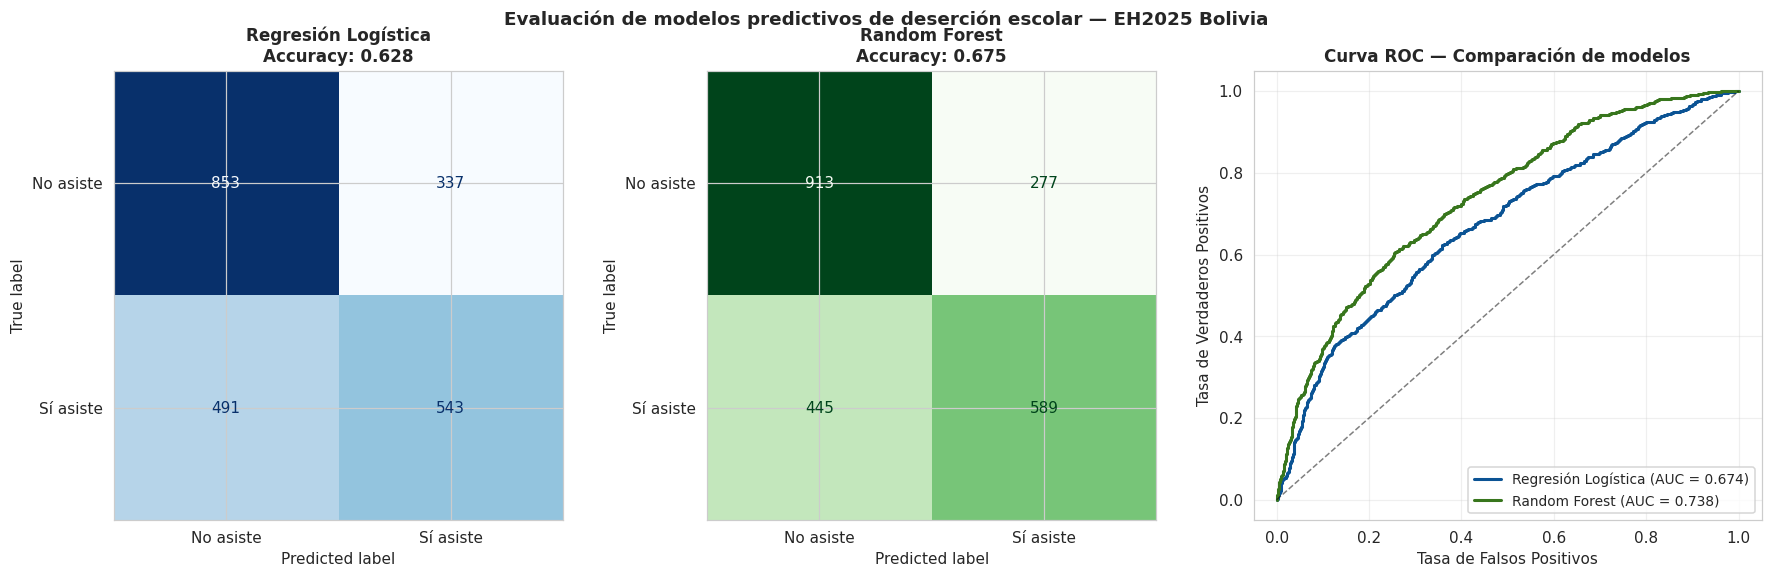

✓ Guardado: 05_modelos_evaluacion.png


In [28]:
# --- VISUALIZACIÓN 5: Matrices de confusión y curva ROC ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

# Matriz confusión LR
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No asiste', 'Sí asiste'])
disp_lr.plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title(f'Regresión Logística\nAccuracy: {accuracy_score(y_test, y_pred_lr):.3f}',
                   fontsize=11, fontweight='bold')

# Matriz confusión RF
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No asiste', 'Sí asiste'])
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False, values_format='d')
axes[1].set_title(f'Random Forest\nAccuracy: {accuracy_score(y_test, y_pred_rf):.3f}',
                   fontsize=11, fontweight='bold')

# Curva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
axes[2].plot(fpr_lr, tpr_lr, color=PALETTE['primary'], linewidth=2,
             label=f'Regresión Logística (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
axes[2].plot(fpr_rf, tpr_rf, color=PALETTE['secondary'], linewidth=2,
             label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
axes[2].set_xlabel('Tasa de Falsos Positivos', fontsize=10)
axes[2].set_ylabel('Tasa de Verdaderos Positivos', fontsize=10)
axes[2].set_title('Curva ROC — Comparación de modelos', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9, loc='lower right')
axes[2].grid(True, alpha=0.3)

fig.suptitle('Evaluación de modelos predictivos de deserción escolar — EH2025 Bolivia',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig(IMAGES_DIR / "05_modelos_evaluacion.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Guardado: 05_modelos_evaluacion.png")

## 3.6 VISUALIZACIÓN 6: Importancia de variables

In [29]:
# --- 3.7 Importancia de variables ---
importancia = pd.DataFrame({
    'variable': X.columns,
    'importancia': rf.feature_importances_,
}).sort_values('importancia', ascending=False)

print("Top 15 variables más importantes:")
print(importancia.head(15).to_string(index=False))

# Etiquetas amigables
labels_map = {
    'edad': 'Edad del estudiante',
    'log_ingreso_pc': 'Log-ingreso per cápita hogar',
    'jefe_anios_estudio': 'Años de estudio del jefe/a',
    'hacinamiento': 'Hacinamiento (personas/cuarto)',
    'log_alquiler': 'Log-alquiler estimado (riqueza)',
    'indice_servicios': 'Índice de servicios básicos',
    'trabajo_bin': 'Estudiante trabaja',
    'internet_bin': 'Internet en el hogar',
    'lee_escribe_bin': 'Sabe leer y escribir',
    'jefe_edad': 'Edad del jefe/a de hogar',
    'sexo_bin': 'Sexo (1=Hombre)',
    'indigena_bin': 'Autoidentificación indígena',
    'idioma_originario': 'Idioma materno originario',
    'piso_adecuado': 'Piso adecuado (no tierra)',
    'pared_adecuada': 'Paredes adecuadas',
    'jefe_sexo': 'Sexo del jefe/a',
    'area_nombre_Urbana': 'Zona urbana',
    'depto_nombre_La Paz': 'Departamento La Paz',
    'depto_nombre_Santa Cruz': 'Departamento Santa Cruz',
    'depto_nombre_Cochabamba': 'Departamento Cochabamba',
    'depto_nombre_Potosí': 'Departamento Potosí',
    'depto_nombre_Oruro': 'Departamento Oruro',
    'depto_nombre_Chuquisaca': 'Departamento Chuquisaca',
    'depto_nombre_Tarija': 'Departamento Tarija',
    'depto_nombre_Beni': 'Departamento Beni',
    'depto_nombre_Pando': 'Departamento Pando',
}
top10 = importancia.head(10).copy()
top10['variable_label'] = top10['variable'].map(lambda x: labels_map.get(x, x))

Top 15 variables más importantes:
               variable  importancia
    depto_nombre_La Paz     0.310393
         log_ingreso_pc     0.082824
              jefe_edad     0.065968
           log_alquiler     0.059704
     jefe_anios_estudio     0.054233
           hacinamiento     0.053763
depto_nombre_Chuquisaca     0.050286
                   edad     0.044210
       indice_servicios     0.037074
            trabajo_bin     0.029457
           internet_bin     0.027123
     area_nombre_Urbana     0.024822
depto_nombre_Cochabamba     0.023068
    depto_nombre_Tarija     0.021005
     depto_nombre_Oruro     0.019248


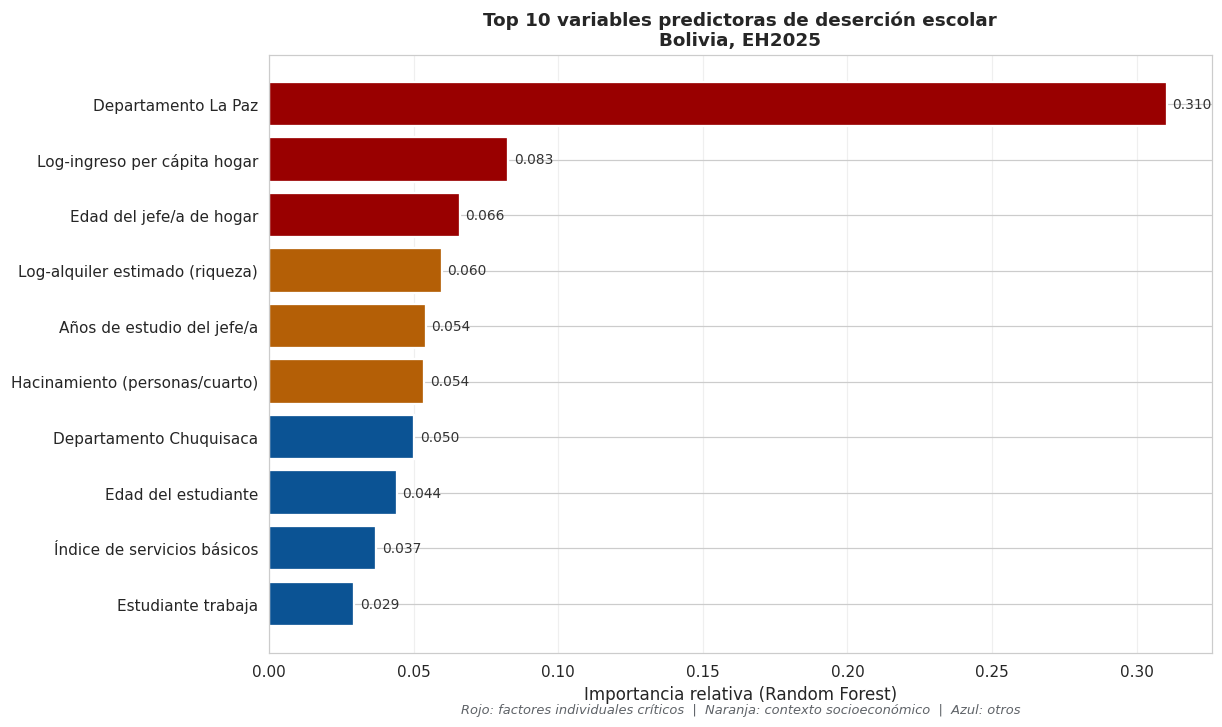

✓ Guardado: 06_importancia_variables.png


In [30]:
# --- VISUALIZACIÓN 6: Importancia de variables ---
fig, ax = plt.subplots(figsize=(11, 6.5), constrained_layout=True)
colors = [PALETTE['danger'] if i < 3 else
          PALETTE['accent'] if i < 6 else
          PALETTE['primary']
          for i in range(len(top10))]
bars = ax.barh(top10['variable_label'][::-1], top10['importancia'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=1.5)
ax.set_xlabel('Importancia relativa (Random Forest)', fontsize=11)
ax.set_title('Top 10 variables predictoras de deserción escolar\nBolivia, EH2025',
             fontsize=12, fontweight='bold')
for bar, v in zip(bars, top10['importancia'][::-1]):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.3f}',
            va='center', fontsize=9, color='#333')
ax.grid(True, axis='x', alpha=0.3)
legend_text = "Rojo: factores individuales críticos  |  Naranja: contexto socioeconómico  |  Azul: otros"
ax.text(0.5, -0.10, legend_text, transform=ax.transAxes, ha='center',
        fontsize=8.5, style='italic', color=PALETTE['neutral'])

plt.savefig(IMAGES_DIR / "06_importancia_variables.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Guardado: 06_importancia_variables.png")